# TechNova GmbH — Cloud Cost Optimization Analysis
### Client: TechNova GmbH | Analyst: Cortex Reply FinOps Team | Period: Jan–Jun 2024

---

## Project Background

> **From:** Marcus Weber, CTO — TechNova GmbH
> **To:** Cortex Reply FinOps Team
> **Subject:** AWS Cost Optimization Engagement
>
> We're a fast-growing SaaS company running our entire platform on AWS. We have **5 engineering teams** (Backend, Data Platform, DevOps, Mobile, ML-Engineering) operating across **4 AWS regions** (Frankfurt, Ireland, Virginia, Singapore).
>
> Our cloud spend has been climbing over the past 6 months and leadership wants a full optimization review before we plan next year's budget. We use a mix of pricing models (On-Demand, Reserved, Spot) but we're not sure if we're using them correctly.
>
> We need you to analyze **6 months of AWS data (Jan–Jun 2024)** and answer:
> 1. Where is our money going — by team, region, service, and environment?
> 2. Are we using the right pricing model for each workload?
> 3. Which resources are idle or overprovisioned?
> 4. Are we running resources in expensive regions unnecessarily?
> 5. What are our biggest savings opportunities and what should we prioritize?
>
> — Marcus Weber, CTO

---

## Objectives
1. Explore and clean the data
2. Engineer useful features for deeper analysis
3. Merge the three datasets
4. Analyze cost across teams, regions, services, environments, and pricing models
5. Identify idle resources, overprovisioning, pricing inefficiency, and regional waste
6. Quantify savings and prioritize recommendations

---

## Datasets

| File | Description | Rows | Columns |
|------|-------------|------|---------|
| `v2_aws_billing.csv` | AWS Cost & Usage data — cost, service, region, pricing term, tags | 300 | 16 |
| `v2_usage_metrics.csv` | CPU & memory utilization for EC2, RDS, ElastiCache | 300 | 12 |
| `v2_resource_inventory.csv` | Resource ownership metadata — team, owner, cost center, environment | 300 | 11 |


## 1. Setup & Loading Data

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [51]:
billing   = pd.read_csv('v2_aws_billing.csv')
usage     = pd.read_csv('v2_usage_metrics.csv')
inventory = pd.read_csv('v2_resource_inventory.csv')

## 2. Explore the Data

Before cleaning, we inspect each dataset — structure, data types, missing values, and the unique values in key columns.

*Exploration: inspect `billing.info()`, `usage.info()`, `inventory.info()`, preview with `.head()`, and check unique values in `service`, `region`, `pricing_term`, and `tag_team`.*

## 3. Data Cleaning

Steps:
- Remove duplicate rows (keep one row per resource per month)
- Convert date columns to datetime
- Normalize inconsistent environment values (prod/production, dev/development)
- Fill untagged billing rows and missing inventory metadata
- Convert USD costs to EUR

In [53]:
# ── STEP 3: DATA CLEANING ────────────────────────────────────────────────

# 1. Convert date columns to datetime
billing['usage_start_date'] = pd.to_datetime(billing['usage_start_date'])
billing['usage_end_date']   = pd.to_datetime(billing['usage_end_date'])
inventory['created_date']   = pd.to_datetime(inventory['created_date'])

In [54]:
# Remove duplicate rows (keep first occurrence of each resource per month)
billing   = billing.drop_duplicates(subset=['resource_id','billing_period'])
usage     = usage.drop_duplicates(subset=['resource_id','billing_period'])
inventory = inventory.drop_duplicates(subset=['resource_id','billing_period'])

print("After dedup:")
print("billing:", len(billing))
print("usage:", len(usage))
print("inventory:", len(inventory))

After dedup:
billing: 300
usage: 228
inventory: 300


In [55]:
# 2. Normalize inconsistent environment values (prod/production, dev/development)
env_map = {
    'prod':'production','production':'production',
    'dev':'development','development':'development',
    'staging':'staging'
}
billing['tag_environment'] = billing['tag_environment'].map(env_map)
inventory['environment']   = inventory['environment'].map(env_map)


In [56]:
# 3. Fill untagged billing rows
billing['tag_team']        = billing['tag_team'].fillna('untagged')
billing['tag_environment'] = billing['tag_environment'].fillna('untagged')
billing['tag_project']     = billing['tag_project'].fillna('untagged')


In [57]:
# 4. Fill missing inventory metadata
inventory['owner_email'] = inventory['owner_email'].fillna('no-owner')
inventory['cost_center'] = inventory['cost_center'].fillna('unassigned')
inventory['environment'] = inventory['environment'].fillna('unknown')

In [58]:

# 5. Convert USD to EUR
billing['cost_eur'] = (billing['unblended_cost'] * 0.92).round(2)


## 4. Feature Engineering

We create new columns to power deeper analysis:
- **On billing:** `is_untagged`, `region_tier`, `is_non_prod`, `cost_rank_in_month`, `month_num`
- **On usage:** `is_idle`, `safe_to_downsize`, `memory_bound`, `utilization_category`

The `memory_bound` flag is important — it identifies resources with low CPU but high memory, which must NOT be downsized even though they look idle.

In [60]:
# 1. Is this resource untagged? (boolean flag for easy filtering)
billing['is_untagged'] = (billing['tag_team'] == 'untagged')

In [61]:
# 2. Region grouping — is it a low-cost or high-cost region?
#    us-east-1 is cheapest, ap-southeast-1 (Singapore) is most expensive
region_tier = {
    'us-east-1':'low-cost',
    'eu-west-1':'standard',
    'eu-central-1':'standard',
    'ap-southeast-1':'high-cost'
}
billing['region_tier'] = billing['region'].map(region_tier)

In [62]:
# 3. Is this a non-production environment? (dev/staging shouldn't run 24/7)
billing['is_non_prod'] = billing['tag_environment'].isin(['development','staging'])

In [63]:
# 4. Cost rank within each month (1 = most expensive line item that month)
billing['cost_rank_in_month'] = billing.groupby('billing_period')['cost_eur'].rank(ascending=False)

In [64]:
# 5. Extract month number for trend ordering
billing['month_num'] = billing['billing_period'].str[-2:].astype(int)


In [65]:
# Quick check
print(billing[['service','region','region_tier','tag_environment','is_non_prod','is_untagged','cost_eur']].head(8))
print("\nNew columns added:", ['is_untagged','region_tier','is_non_prod','cost_rank_in_month','month_num'])

             service          region region_tier tag_environment  is_non_prod  \
0         Amazon EC2    eu-central-1    standard      production        False   
1         Amazon EC2       eu-west-1    standard      production        False   
2  Amazon CloudFront       us-east-1    low-cost        untagged        False   
3         AWS Lambda       us-east-1    low-cost      production        False   
4  Amazon CloudFront  ap-southeast-1   high-cost      production        False   
5  Amazon CloudFront  ap-southeast-1   high-cost      production        False   
6         AWS Lambda    eu-central-1    standard     development         True   
7         Amazon SQS    eu-central-1    standard      production        False   

   is_untagged  cost_eur  
0        False     33.55  
1        False    240.23  
2        False    630.17  
3        False      0.33  
4        False    409.02  
5        False    294.36  
6        False      0.54  
7        False      2.24  

New columns added: ['is_un

### 4.1 Feature Engineering on Usage Data

In [67]:
# 1. Idle flag — avg CPU < 10% AND max CPU < 20% (truly idle, not just bursty)
usage['is_idle'] = (usage['avg_cpu_utilization_pct'] < 10) & (usage['max_cpu_utilization_pct'] < 20)

In [68]:
# 2. Overprovisioned flag — low CPU but we must check memory too
#    Safe to downsize only if BOTH cpu and memory are low
usage['safe_to_downsize'] = (
    (usage['avg_cpu_utilization_pct'] < 40) &
    (usage['max_cpu_utilization_pct'] < 60) &
    (usage['avg_memory_utilization_pct'] < 40) &
    (usage['max_memory_utilization_pct'] < 60)
)

In [69]:
# 3. Memory-bound flag — low CPU but HIGH memory (do NOT downsize these!)
usage['memory_bound'] = (
    (usage['avg_cpu_utilization_pct'] < 15) &
    (usage['avg_memory_utilization_pct'] > 75)
)

In [70]:
# 4. Utilization category for easy grouping
def categorize(row):
    if row['avg_cpu_utilization_pct'] < 10:
        return 'idle'
    elif row['avg_cpu_utilization_pct'] < 40:
        return 'underutilized'
    elif row['avg_cpu_utilization_pct'] < 80:
        return 'healthy'
    else:
        return 'high'
usage['utilization_category'] = usage.apply(categorize, axis=1)

In [73]:
# Check
print(usage['utilization_category'].value_counts())
print("\nIdle instances:", usage['is_idle'].sum())
print("Safe to downsize:", usage['safe_to_downsize'].sum())
print("Memory-bound (do NOT downsize):", usage['memory_bound'].sum())

utilization_category
healthy          89
idle             54
underutilized    50
high             35
Name: count, dtype: int64

Idle instances: 54
Safe to downsize: 78
Memory-bound (do NOT downsize): 26


## 5. Merge the Datasets

We merge all 3 datasets into one enriched dataframe `df` using `billing` as the base table.

- **Join keys:** `resource_id` + `billing_period` (both needed because resources repeat across months)
- **Type:** LEFT JOIN — keep all billing rows
- We select only the specific columns needed from inventory and usage to avoid duplicate columns and keep the merge safe to re-run.

**Expected result:** 300 rows, no row explosion.

In [92]:
# ── MERGE (safe to re-run) ───────────────────────────────────────────────
# Only bring columns from inventory/usage that billing doesn't already have
inv_cols = ['resource_id','billing_period','owner_email','cost_center','is_active','created_date']
use_cols = ['resource_id','billing_period','instance_type','avg_cpu_utilization_pct',
            'max_cpu_utilization_pct','avg_memory_utilization_pct','max_memory_utilization_pct',
            'running_on_weekends','is_idle','safe_to_downsize','memory_bound','utilization_category']

df = billing.merge(inventory[inv_cols], on=['resource_id','billing_period'], how='left')
df = df.merge(usage[use_cols], on=['resource_id','billing_period'], how='left')

print("Merged shape:", df.shape)
print("Duplicate columns:", df.columns[df.columns.duplicated()].tolist())

Merged shape: (300, 36)
Duplicate columns: []


## 6. Analysis

Nine analyses covering cost trends, service/team/region/environment breakdowns, pricing model efficiency, untagged spend, and idle/overprovisioned resources.

### 6.1 Monthly Cost Trend

**Question:** Is the bill growing? Which month spiked?

In [95]:
# ── ANALYSIS 1: Monthly cost trend ───────────────────────────────────────
monthly = df.groupby('billing_period')['cost_eur'].sum().round(2).reset_index()
monthly.columns = ['month','total_cost_eur']
print(monthly)
print(f"\nTotal 6-month spend: €{df['cost_eur'].sum():,.2f}")

     month  total_cost_eur
0  2024-01         6677.90
1  2024-02         5137.49
2  2024-03         4855.14
3  2024-04         8000.54
4  2024-05         6237.55
5  2024-06         6963.71

Total 6-month spend: €37,872.33


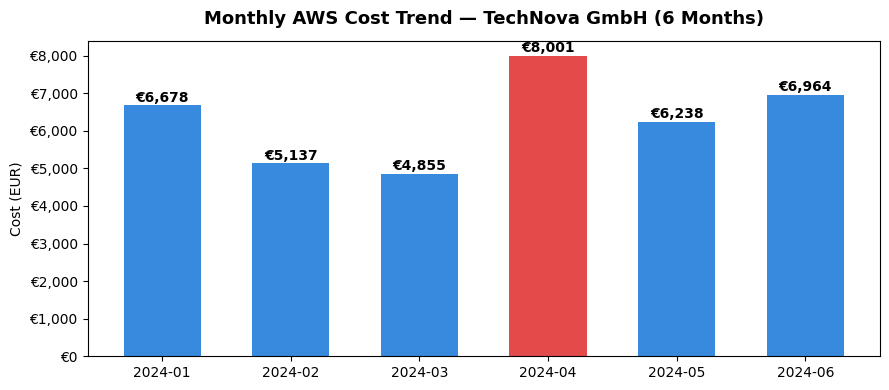

In [96]:
fig, ax = plt.subplots(figsize=(9, 4))

# Color April red (the spike), rest blue
colors = ['#378ADD' if m != '2024-04' else '#E24B4A' for m in monthly['month']]
ax.bar(monthly['month'], monthly['total_cost_eur'], color=colors, width=0.6)

ax.set_title('Monthly AWS Cost Trend — TechNova GmbH (6 Months)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, row in monthly.iterrows():
    ax.text(i, row['total_cost_eur'] + 100, f"€{row['total_cost_eur']:,.0f}",
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.2 Cost by Service

**Question:** Which AWS service drives the most spend?

In [97]:
# ── ANALYSIS 2: Cost by service ──────────────────────────────────────────
by_service = df.groupby('service')['cost_eur'].sum().sort_values(ascending=False).round(2)
print(by_service)

service
Amazon EC2            13183.72
Amazon S3              7130.14
Amazon CloudFront      6400.50
Amazon RDS             4366.06
AWS Data Transfer      3653.13
Amazon ElastiCache     2304.90
Amazon EKS              773.46
Amazon SQS               32.39
Amazon DynamoDB          17.06
AWS Lambda               10.97
Name: cost_eur, dtype: float64


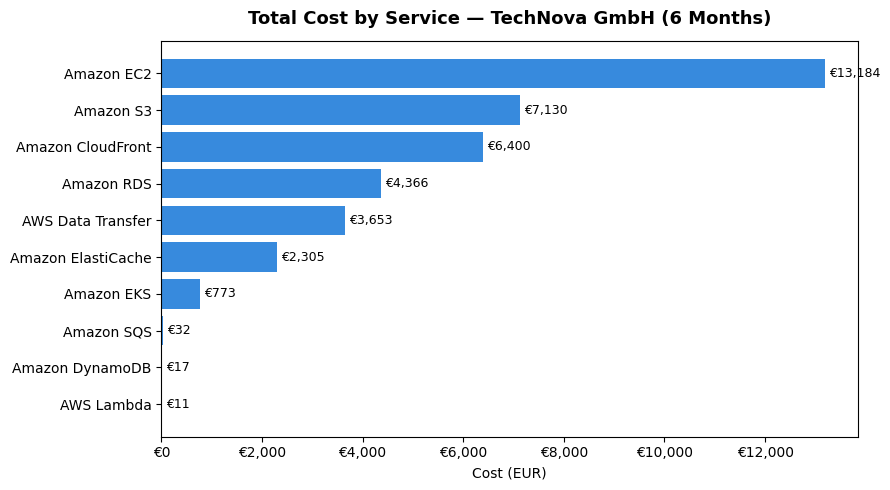

In [98]:
fig, ax = plt.subplots(figsize=(9, 5))

bs = by_service.sort_values(ascending=True)
ax.barh(bs.index, bs.values, color='#378ADD')

ax.set_title('Total Cost by Service — TechNova GmbH (6 Months)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cost (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, val in enumerate(bs.values):
    ax.text(val + 80, i, f'€{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 6.3 Cost by Team

**Question:** Which team spends the most? How much is untagged?

In [99]:
# ── ANALYSIS 3: Cost by team ─────────────────────────────────────────────
by_team = df.groupby('tag_team')['cost_eur'].sum().sort_values(ascending=False).round(2)
print(by_team)

tag_team
untagged          9355.56
ml-engineering    7585.41
backend           6005.43
mobile            5972.32
devops            5336.61
data-platform     3617.00
Name: cost_eur, dtype: float64


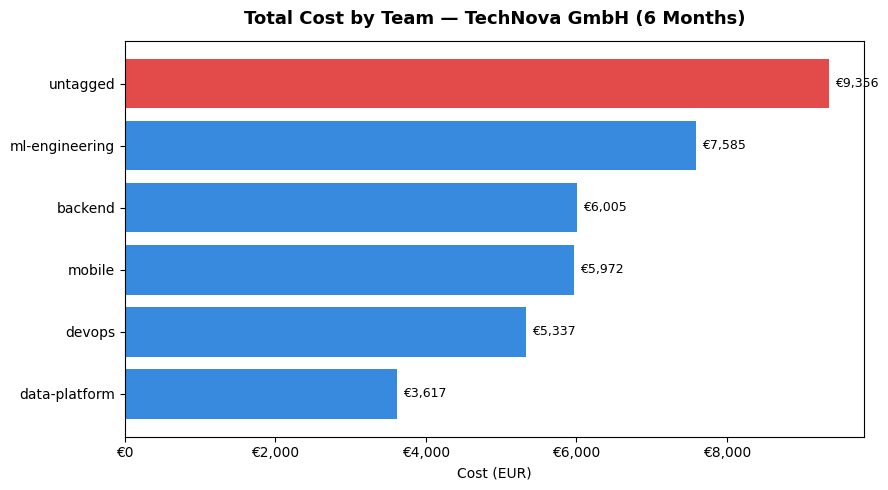

In [100]:
fig, ax = plt.subplots(figsize=(9, 5))

bt = by_team.sort_values(ascending=True)
colors = ['#E24B4A' if t == 'untagged' else '#378ADD' for t in bt.index]
ax.barh(bt.index, bt.values, color=colors)

ax.set_title('Total Cost by Team — TechNova GmbH (6 Months)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cost (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, val in enumerate(bt.values):
    ax.text(val + 80, i, f'€{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 6.4 Cost by Region

**Question:** Where is spend concentrated? Any waste in expensive regions?

In [101]:
# ── ANALYSIS 4: Cost by region ───────────────────────────────────────────
by_region = df.groupby('region')['cost_eur'].sum().sort_values(ascending=False).round(2)
print(by_region)

# Also show cost by region tier (low-cost / standard / high-cost)
print("\nBy region tier:")
print(df.groupby('region_tier')['cost_eur'].sum().sort_values(ascending=False).round(2))

region
eu-central-1      19271.00
eu-west-1          8840.05
us-east-1          6773.39
ap-southeast-1     2987.89
Name: cost_eur, dtype: float64

By region tier:
region_tier
standard     28111.05
low-cost      6773.39
high-cost     2987.89
Name: cost_eur, dtype: float64


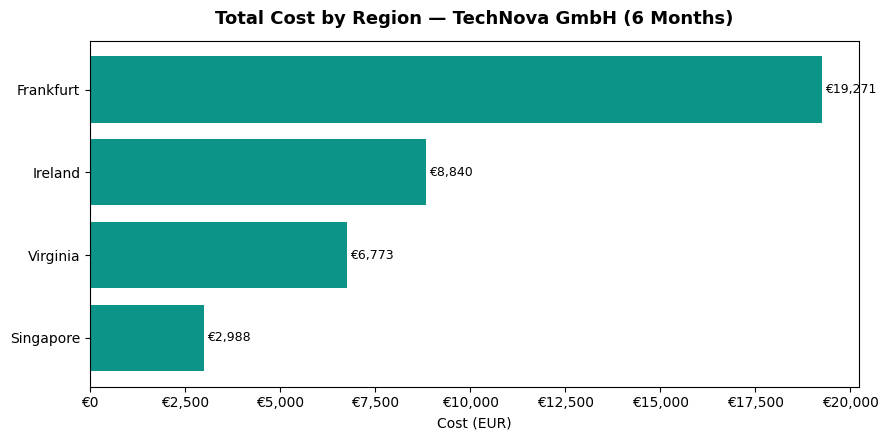

In [102]:
fig, ax = plt.subplots(figsize=(9, 4.5))

region_names = {
    'eu-central-1': 'Frankfurt',
    'eu-west-1': 'Ireland',
    'us-east-1': 'Virginia',
    'ap-southeast-1': 'Singapore'
}
br = by_region.sort_values(ascending=True)
labels = [region_names.get(r, r) for r in br.index]

ax.barh(labels, br.values, color='#0D9488')

ax.set_title('Total Cost by Region — TechNova GmbH (6 Months)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cost (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, val in enumerate(br.values):
    ax.text(val + 80, i, f'€{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 6.5 Cost by Environment

**Question:** How much goes to non-production (dev/staging)?

In [103]:
# ── ANALYSIS 5: Cost by environment ──────────────────────────────────────
by_env = df.groupby('tag_environment')['cost_eur'].sum().sort_values(ascending=False).round(2)
print(by_env)

# Non-production spend (dev + staging) — candidates for shutdown
non_prod = df[df['tag_environment'].isin(['development','staging'])]['cost_eur'].sum()
print(f"\nNon-production spend (dev + staging): €{non_prod:,.2f}")
print(f"% of total: {non_prod / df['cost_eur'].sum() * 100:.1f}%")

tag_environment
untagged       13704.64
production     10735.56
development     8820.34
staging         4611.79
Name: cost_eur, dtype: float64

Non-production spend (dev + staging): €13,432.13
% of total: 35.5%


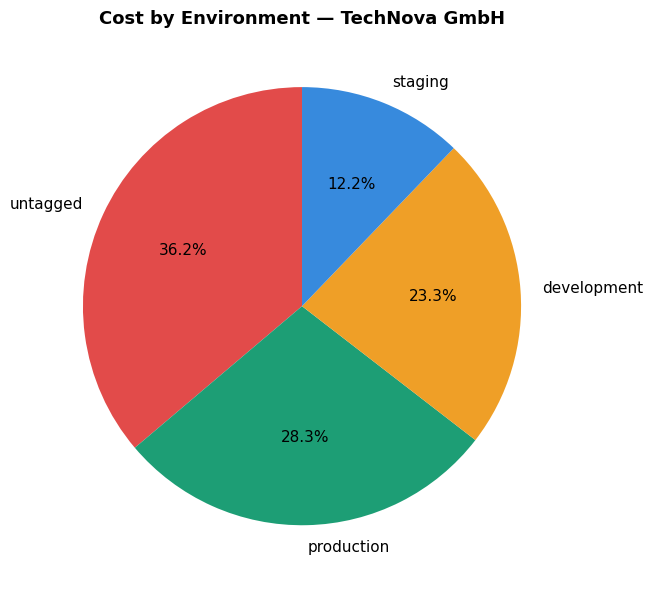

In [104]:
fig, ax = plt.subplots(figsize=(8, 6))

colors_env = {'production':'#1D9E75', 'development':'#EF9F27', 'staging':'#378ADD', 'untagged':'#E24B4A'}
pie_colors = [colors_env.get(e, '#94A3B8') for e in by_env.index]

ax.pie(by_env.values, labels=by_env.index, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 11}, colors=pie_colors)
ax.set_title('Cost by Environment — TechNova GmbH', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.6 Pricing Model Analysis

**Question:** Are OnDemand / Reserved / Spot used on the right workloads?

In [105]:
# ── ANALYSIS 6: Pricing model analysis ───────────────────────────────────

# Overall pricing breakdown
by_pricing = df.groupby('pricing_term')['cost_eur'].sum().sort_values(ascending=False).round(2)
print("Cost by pricing term:")
print(by_pricing)

# The key question: are they using the RIGHT pricing for each environment?
print("\n--- Pricing term by environment ---")
pricing_env = df.groupby(['tag_environment','pricing_term'])['cost_eur'].sum().round(2).reset_index()
pivot = pricing_env.pivot(index='tag_environment', columns='pricing_term', values='cost_eur').fillna(0)
print(pivot)

Cost by pricing term:
pricing_term
OnDemand    20595.56
Reserved    10729.43
Spot         6547.34
Name: cost_eur, dtype: float64

--- Pricing term by environment ---
pricing_term     OnDemand  Reserved     Spot
tag_environment                             
development       3686.77    810.80  4322.77
production        5596.83   4675.69   463.04
staging           2960.94   1330.50   320.35
untagged          8351.02   3912.44  1441.18


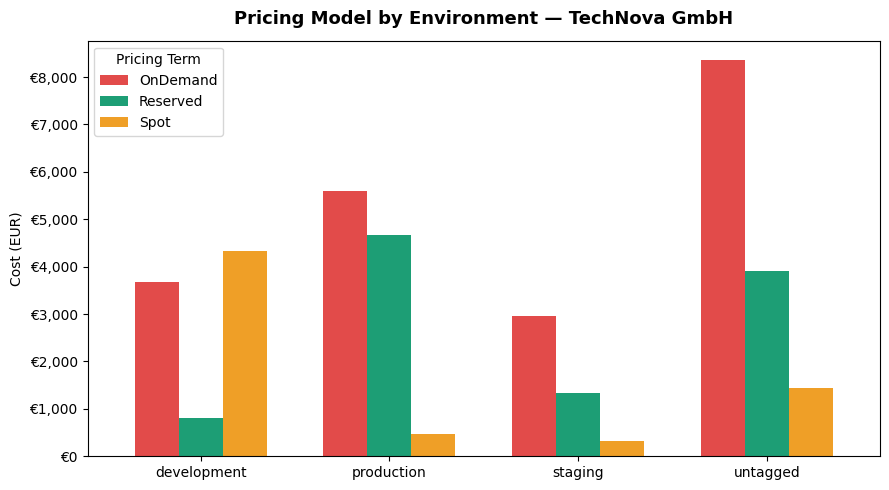

In [106]:
fig, ax = plt.subplots(figsize=(9, 5))

pivot.plot(kind='bar', ax=ax, width=0.7,
           color={'OnDemand':'#E24B4A','Reserved':'#1D9E75','Spot':'#EF9F27'})

ax.set_title('Pricing Model by Environment — TechNova GmbH', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(title='Pricing Term')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 6.7 Untagged Spend Deep-Dive

**Question:** Where is the untagged spend hiding by service and region?

In [107]:
# ── ANALYSIS 7: Untagged spend deep-dive ─────────────────────────────────
untagged_df = df[df['tag_team'] == 'untagged']

print(f"Total untagged spend: €{untagged_df['cost_eur'].sum():,.2f}")
print(f"% of total: {untagged_df['cost_eur'].sum() / df['cost_eur'].sum() * 100:.1f}%")

print("\n--- Untagged by service ---")
untagged_service = untagged_df.groupby('service')['cost_eur'].sum().sort_values(ascending=False).round(2)
print(untagged_service)

print("\n--- Untagged by region ---")
untagged_region = untagged_df.groupby('region')['cost_eur'].sum().sort_values(ascending=False).round(2)
print(untagged_region)

Total untagged spend: €9,355.56
% of total: 24.7%

--- Untagged by service ---
service
Amazon EC2            3075.21
Amazon CloudFront     2010.48
Amazon S3             1777.80
AWS Data Transfer     1164.16
Amazon RDS             801.98
Amazon ElastiCache     363.91
Amazon EKS             147.16
Amazon SQS               9.77
AWS Lambda               2.73
Amazon DynamoDB          2.36
Name: cost_eur, dtype: float64

--- Untagged by region ---
region
eu-central-1      4772.33
eu-west-1         2011.53
us-east-1         1534.13
ap-southeast-1    1037.57
Name: cost_eur, dtype: float64


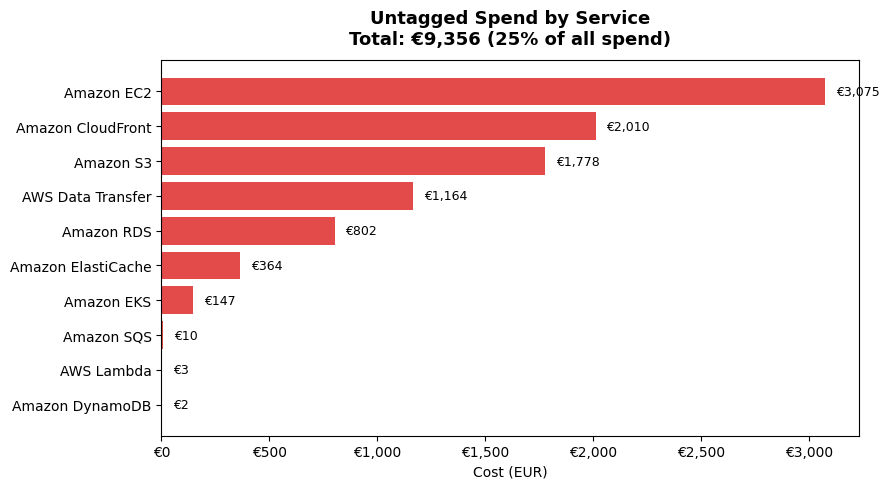

In [108]:
fig, ax = plt.subplots(figsize=(9, 5))

us = untagged_service.sort_values(ascending=True)
ax.barh(us.index, us.values, color='#E24B4A')

ax.set_title(f'Untagged Spend by Service\nTotal: €{untagged_service.sum():,.0f} (25% of all spend)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Cost (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, val in enumerate(us.values):
    ax.text(val + 50, i, f'€{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 6.8 Idle & Overprovisioned Resources

**Question:** Which resources are idle or safe to downsize? (memory-bound excluded)

In [109]:
# ── ANALYSIS 8: Idle & overprovisioned resources ─────────────────────────

# Only look at rows that have usage metrics (EC2, RDS, ElastiCache)
compute = df[df['avg_cpu_utilization_pct'].notna()]

print("=== Resource utilization breakdown ===")
print(compute['utilization_category'].value_counts())

print(f"\n--- Idle resources (avg CPU <10%) ---")
idle = compute[compute['is_idle'] == True]
print(f"Count: {len(idle)}")
print(f"Wasted cost: €{idle['cost_eur'].sum():,.2f}")

print(f"\n--- Safe to downsize (CPU + memory both low) ---")
downsize = compute[compute['safe_to_downsize'] == True]
print(f"Count: {len(downsize)}")
print(f"Cost: €{downsize['cost_eur'].sum():,.2f}")

print(f"\n--- Memory-bound (DO NOT downsize — high memory) ---")
mem_bound = compute[compute['memory_bound'] == True]
print(f"Count: {len(mem_bound)}")
print(f"Cost: €{mem_bound['cost_eur'].sum():,.2f}")

=== Resource utilization breakdown ===
utilization_category
healthy          58
underutilized    40
idle             32
high             29
Name: count, dtype: int64

--- Idle resources (avg CPU <10%) ---
Count: 32
Wasted cost: €3,476.27

--- Safe to downsize (CPU + memory both low) ---
Count: 55
Cost: €6,574.40

--- Memory-bound (DO NOT downsize — high memory) ---
Count: 17
Cost: €2,164.44


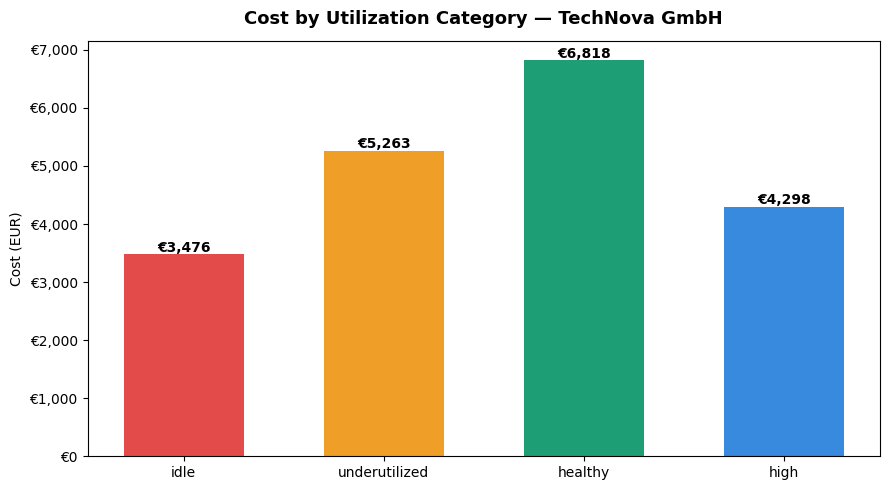

In [110]:
fig, ax = plt.subplots(figsize=(9, 5))

cat_cost = compute.groupby('utilization_category')['cost_eur'].sum().reindex(['idle','underutilized','healthy','high']).fillna(0)
colors_cat = ['#E24B4A','#EF9F27','#1D9E75','#378ADD']

bars = ax.bar(cat_cost.index, cat_cost.values, color=colors_cat, width=0.6)

ax.set_title('Cost by Utilization Category — TechNova GmbH', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Cost (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for bar, val in zip(bars, cat_cost.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'€{val:,.0f}',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.9 Savings Opportunity Summary

**Question:** What is the total savings potential and how should we prioritize?

In [111]:
# ── ANALYSIS 9: Savings opportunity summary ──────────────────────────────

# 1. Idle resources — could be shut down (assume 80% reduction)
idle_saving = idle['cost_eur'].sum() * 0.80

# 2. Safe to downsize — rightsizing saves ~50% (move to half-size instance)
#    Exclude memory-bound (already excluded in safe_to_downsize flag)
downsize_saving = downsize['cost_eur'].sum() * 0.50

# 3. Production OnDemand → Reserved (saves 40%)
prod_ondemand = df[(df['tag_environment']=='production') & (df['pricing_term']=='OnDemand')]['cost_eur'].sum()
ri_saving = prod_ondemand * 0.40

# 4. Non-prod auto-shutdown nights/weekends (saves ~60% of dev+staging)
non_prod_cost = df[df['tag_environment'].isin(['development','staging'])]['cost_eur'].sum()
shutdown_saving = non_prod_cost * 0.60

print("=" * 55)
print("SAVINGS OPPORTUNITY SUMMARY — TechNova GmbH (6 months)")
print("=" * 55)
print(f"\n1. Shut down idle resources:        €{idle_saving:>9,.2f}")
print(f"2. Rightsize overprovisioned:       €{downsize_saving:>9,.2f}")
print(f"3. Production OnDemand → Reserved:   €{ri_saving:>9,.2f}")
print(f"4. Auto-shutdown dev/staging:        €{shutdown_saving:>9,.2f}")

total_saving = idle_saving + downsize_saving + ri_saving + shutdown_saving
total_spend = df['cost_eur'].sum()

print(f"\n{'─'*55}")
print(f"Total savings potential:            €{total_saving:>9,.2f}")
print(f"Current 6-month spend:              €{total_spend:>9,.2f}")
print(f"Potential reduction:                 {total_saving/total_spend*100:>8.1f}%")
print(f"{'─'*55}")

SAVINGS OPPORTUNITY SUMMARY — TechNova GmbH (6 months)

1. Shut down idle resources:        € 2,781.02
2. Rightsize overprovisioned:       € 3,287.20
3. Production OnDemand → Reserved:   € 2,238.73
4. Auto-shutdown dev/staging:        € 8,059.28

───────────────────────────────────────────────────────
Total savings potential:            €16,366.23
Current 6-month spend:              €37,872.33
Potential reduction:                     43.2%
───────────────────────────────────────────────────────


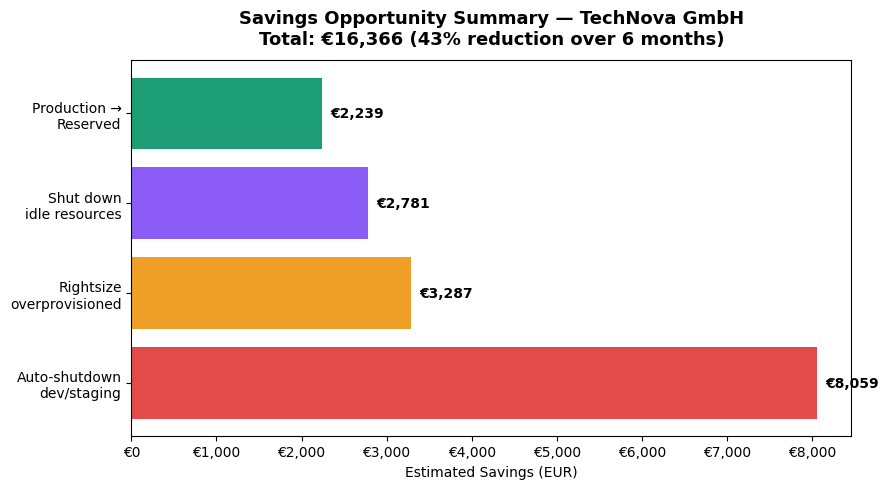

In [112]:
fig, ax = plt.subplots(figsize=(9, 5))

savings = {
    'Auto-shutdown\ndev/staging': 8059.28,
    'Rightsize\noverprovisioned': 3287.20,
    'Shut down\nidle resources': 2781.02,
    'Production →\nReserved': 2238.73,
}
labels = list(savings.keys())
values = list(savings.values())

bars = ax.barh(labels, values, color=['#E24B4A','#EF9F27','#8B5CF6','#1D9E75'])

ax.set_title('Savings Opportunity Summary — TechNova GmbH\nTotal: €16,366 (43% reduction over 6 months)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Estimated Savings (EUR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, val in enumerate(values):
    ax.text(val + 100, i, f'€{val:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Findings, Conclusions & Recommendations
### Client: TechNova GmbH | Prepared by: Cortex Reply FinOps Team | Period: Jan–Jun 2024

---

### Executive Summary
Over 6 months, TechNova GmbH spent €37,872 across 10 AWS services, 5 teams, and 4 regions.
Our analysis identified €16,366 in savings opportunities — a 43% potential cost reduction —
with the largest wins requiring minimal engineering effort.

---

### Finding 1 — 35% of Spend Is Non-Production
- Development (€8,820) + Staging (€4,611) = €13,432 — 35.5% of total spend
- These environments run 24/7 but engineers only use them during business hours
- Production (€10,735) is actually LOWER than non-production — a red flag

**Recommendation:** Implement AWS Instance Scheduler to auto-shutdown dev/staging
outside business hours (Mon–Fri 08:00–20:00). Estimated saving: €8,059.

---

### Finding 2 — 25% of Spend Is Untagged
- €9,355 has no team owner — the single largest cost category
- 73% of untagged spend is in just 3 services: EC2, CloudFront, S3
- Half of it (€4,772) is in the Frankfurt region

**Recommendation:** Enforce tagging via AWS Config Rules. Prioritize EC2, CloudFront,
and S3 in Frankfurt first to recover visibility on €6,862 quickly.

---

### Finding 3 — Resources Are Overprovisioned
- 55 resources are safe to downsize (both CPU and memory low) = €6,574 in spend
- 32 resources are idle (avg CPU <10%) = €3,476 wasted
- IMPORTANT: 17 memory-bound resources (low CPU, high memory) were EXCLUDED from
  rightsizing — downsizing these would crash the workloads

**Recommendation:** Rightsize the 55 safe candidates (save €3,287) and shut down the
32 idle resources (save €2,781). Never rightsize on CPU alone — always check memory.

---

### Finding 4 — Production Has the Wrong Pricing Mix
- Production OnDemand: €5,596 vs Production Reserved: €4,675
- Production runs 24/7 — it should be mostly Reserved, not On-Demand
- Positive: Development is using Spot well (€4,322) — smart, keep it

**Recommendation:** Move steady production OnDemand workloads to 1-year Reserved
Instances. Estimated saving: €2,238 (40% on the eligible amount).

---

### Savings Summary

| # | Finding | 6-Month Saving | Effort | Priority |
|---|---------|----------------|--------|----------|
| 1 | Auto-shutdown dev/staging | €8,059 | Low | High |
| 2 | Rightsize overprovisioned | €3,287 | Medium | High |
| 3 | Shut down idle resources | €2,781 | Low | High |
| 4 | Production → Reserved | €2,238 | Medium | Medium |
| | **Total** | **€16,366** | | **43% reduction** |

---

### Conclusion
TechNova has matured beyond the basics — they're already using Reserved Instances and
Spot in places, and their dev team uses Spot well. However, three core issues remain:
non-production resources running 24/7, a quarter of spend untagged, and production
still over-reliant on On-Demand pricing.

The priority is clear: auto-shutting down dev/staging is a low-effort change that alone
delivers half the total savings. Combined with tagging enforcement and rightsizing,
TechNova can responsibly cut 43% of cloud spend without affecting production performance.

The recommended sequence: (1) auto-shutdown non-prod, (2) enforce tagging, (3) rightsize
and shut down idle resources, (4) optimize production pricing. This moves TechNova from
the Inform phase firmly into the Operate phase of the FinOps lifecycle.